# MIT-BIH Data Exploration\n\nLoad record `100` from the MIT-BIH Arrhythmia Database and plot the first 500 samples of its signal.

In [1]:
import wfdb
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "raw" / "mit-bih-arrhythmia-database-1.0.0"
RECORD_NAME = "100"

In [2]:
record = wfdb.rdrecord(str(DATA_DIR / RECORD_NAME))
print(f"Record: {record.record_name}")
print(f"Signals: {record.sig_name}")
print(f"Sampling frequency: {record.fs} Hz")
print(f"Signal shape: {record.p_signal.shape}")

Record: 100
Signals: ['MLII', 'V5']
Sampling frequency: 360 Hz
Signal shape: (650000, 2)


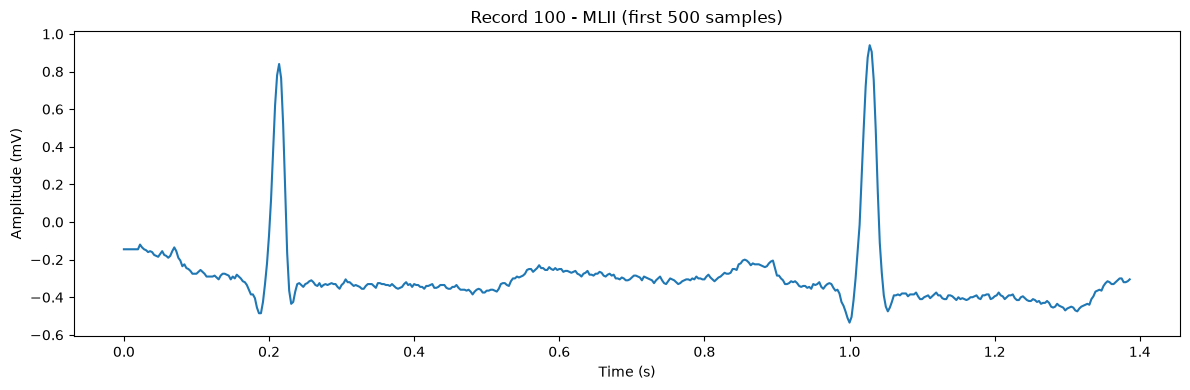

In [3]:
N_SAMPLES = 500
signal = record.p_signal[:N_SAMPLES, 0]
channel_name = record.sig_name[0]
time = [i / record.fs for i in range(N_SAMPLES)]

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.title(f"Record {RECORD_NAME} - {channel_name} (first {N_SAMPLES} samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

## Browse beats by AAMI class

Plot one example beat window for each AAMI EC57 superclass (`N`, `S`, `V`, `F`, `Q`) from `data/processed/beat_windows.npy` / `beat_metadata.csv`.

Found 88265 beats with class 'N'
Found 2769 beats with class 'S'
Found 6965 beats with class 'V'
Found 798 beats with class 'F'
Found 15 beats with class 'Q'


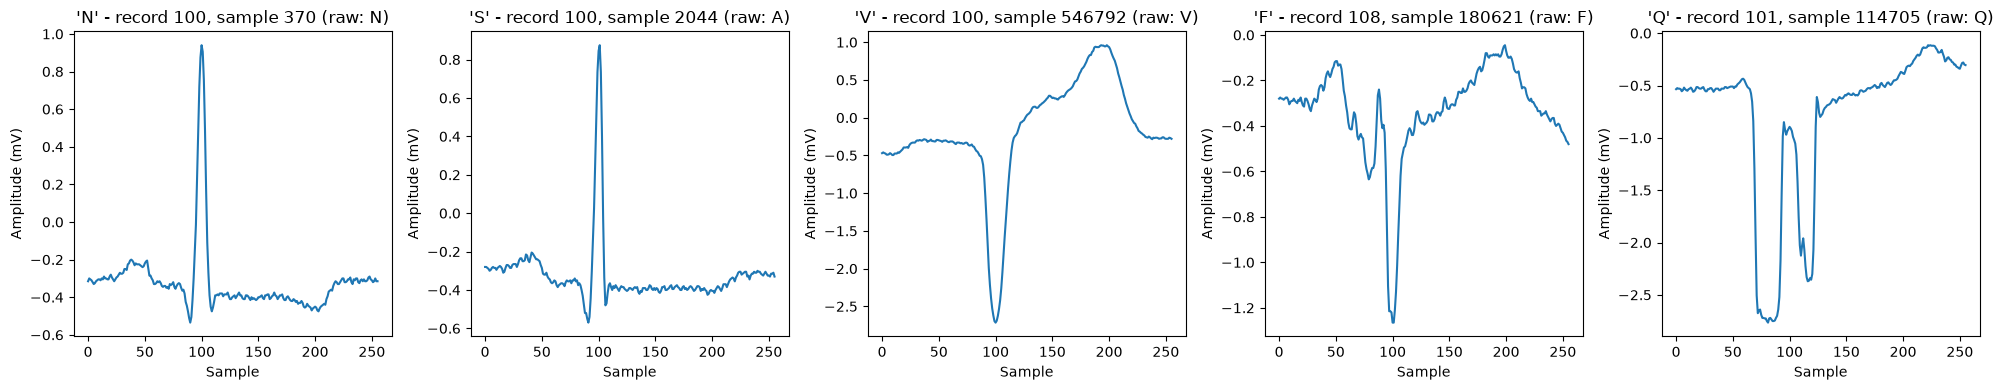

In [4]:
import csv
import numpy as np

PROCESSED_DIR = Path("..") / "data" / "processed"

beat_windows = np.load(PROCESSED_DIR / "beat_windows.npy")
with open(PROCESSED_DIR / "beat_metadata.csv", newline="") as f:
    beat_meta = list(csv.DictReader(f))

AAMI_CLASSES = ["N", "S", "V", "F", "Q"]

fig, axes = plt.subplots(1, len(AAMI_CLASSES), figsize=(4 * len(AAMI_CLASSES), 4))
for ax, cls in zip(axes, AAMI_CLASSES):
    matching = [row for row in beat_meta if row["aami_label"] == cls]
    print(f"Found {len(matching)} beats with class '{cls}'")
    if not matching:
        ax.set_title(f"class '{cls}' (no examples)")
        continue

    row = matching[0]
    window = beat_windows[int(row["window_idx"])]
    ax.plot(window)
    ax.set_title(f"'{cls}' - record {row['record_id']}, sample {row['r_peak_sample']} (raw: {row['raw_symbol']})")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()